# MC test... test.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np      
from scipy.integrate import complex_ode

from tasks import make_static_sin_task
from encoding_masking import build_masked_input, compute_tdm_params
from Reservoirs.ELM_static import run_elm_static, ELMStaticParams
from readout import split_states_targets, fit_ridge_readout, predict_readout
from metrics import mse, nrmse
from Reservoirs.LangKobayashi import expand_virtual_nodes, simulate_lk, simulate_lk_mini, extract_R_from_E, intensities_after_theta_times, charge_at_theta_intervals
from MC_test import linear_memory_curve, plot_memory_curve

In [2]:
rng = np.random.default_rng(0)

L = 1000       
N = 20
u = rng.uniform(-1.0, 1.0, size=L) #input

#reservoir parameters:
p = 0.05 
eta = 0.01 
alpha = 0 
phi = 0.0 
TLk = 50
kappa = 0.1 
D_noise = 10**-7*0

xi = 0 #for now

task_seed = 0
mask_seed = 42


#g = 1.0
ridge_alpha = 0
split = 0.8

theta = 22
dt = 0.1
tau_factor = 1.41 #as per the Kathy Ludge paper.

TDM_parameters = compute_tdm_params(N, theta, dt, tau_factor)

tap_stride = TDM_parameters.tap_stride
Nd_loop = TDM_parameters.Nd_loop 
Nd_delay = TDM_parameters.Nd_delay    
tau = TDM_parameters.tau
print(TDM_parameters)

TDMParams(N=20, theta=22, dt=0.1, T=440, tau=620.4, Nd_loop=4400, Nd_delay=6204, tap_stride=220)


In [4]:

# 1) Use u as the scalar task input
# 2) Apply your normal masking / TDM expansion
# Example sketch only — plug in your actual functions
#V, Vs = build_masked_input(u, mask)   # or however your code does it
x_norm, mask, V = build_masked_input(u, N=N) 
Vs = expand_virtual_nodes(V, tap_stride=tap_stride, Nd=Nd_loop)  

# 3) Run LK simulation on Vs
E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, D_noise=D_noise, xi=xi, Tlk=50, E0=1e-3+0j, n0=0.0)

# 4) Extract one state row per input cycle
R = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop)

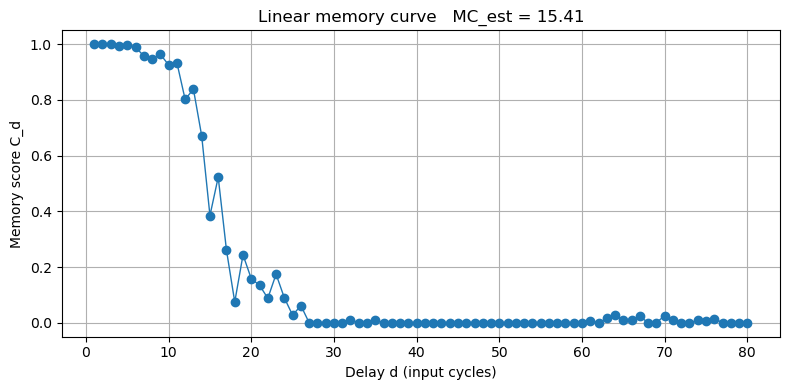

Estimated linear MC: 15.41263080994347


In [5]:
# 5) Benchmark delayed recall
delays, capacities, nrmse, MC_est = linear_memory_curve(R, u, max_delay=80, washout=200, split=0.8, ridge_alpha=1e-6)

plot_memory_curve(delays, capacities, MC_est)
print("Estimated linear MC:", MC_est)